# 3 基于模型的试验设计

既然我们已经掌握了根据已知数据近似构建响应曲面的方法，接下来将着重探讨如何以最优方式采集这类数据。正如第一章所述，我们将采用两阶段试验设计策略：先开展初始设计，再进行序贯设计。在初始设计阶段，我们不对底层输入与输出之间的关联做出任何假设，采集数据的目的是完整拟合整个响应曲面，实现良好近似。在序贯设计阶段，依托初始数据拟合得到的模型继续采集数据，以此达成试验的特定目标，例如优化求解。本章及后续三章将围绕初始设计展开论述，序贯设计相关内容则放在第七章讲解。针对含噪声数据的试验设计方案，将在实物试验章节后续展开推导说明。

## 3.1 基于预测的试验设计

假设存在两个输入变量（$x_1$ 与 $x_2$），且试验预算允许开展七组实验。记试验区域为 $X$，我们需要在该区域内选取七个试验点。若无特殊说明，均假定试验区域可缩放为超立方体，因此本例中 $X = [0, 1]^2$。倘若不借助任何试验设计理论，我们可以在区域 $[0, 1]^2$ 内随机抽取七个样本点，图 3.1 展示了三组此类随机设计方案。不难发现，第一组设计的试验点大多集中在试验区域 $X$ 的左侧，第二组集中在中部，第三组集中在右侧。显然，若要探究区域 $X$ 内输入与输出之间的映射关系，这三组都算不上优质设计。当然也存在例外情况：针对某些特定函数，它们或许会成为最优设计。举例来说，若某函数在左侧变化剧烈、右侧几乎恒定，采用第一组设计就能够较好地拟合该函数。但在试验设计阶段，我们对目标函数一无所知。因此，试验设计的构造原则应当保证：依托采集到的数据，能够精准拟合任意潜在函数。基于该需求，我们需要划定一类函数集合，并寻找平均表现优良或能规避最差情形的试验设计方案。为此，本文将采用克里金法（kriging），也就是高斯过程（GP）所构建的随机分析框架。基于该思路的早期研究成果可参阅萨克斯与伊尔维萨克（1970）、伊尔维萨克（1975）的文献，萨克斯等人（1989）的文章梳理了相关发展历程。后文将会说明，这类基于模型的最优设计无法直接落地应用，原因是其依赖未知的模型参数。不过这套基于模型的分析思路，能够协助我们构建最优设计准则，为下一章设计更具备实用性的试验方案提供理论依据。

> **图 3.1** 在二维区间 $[0, 1]^2$ 内三组包含 7 次运行的随机抽样设计。

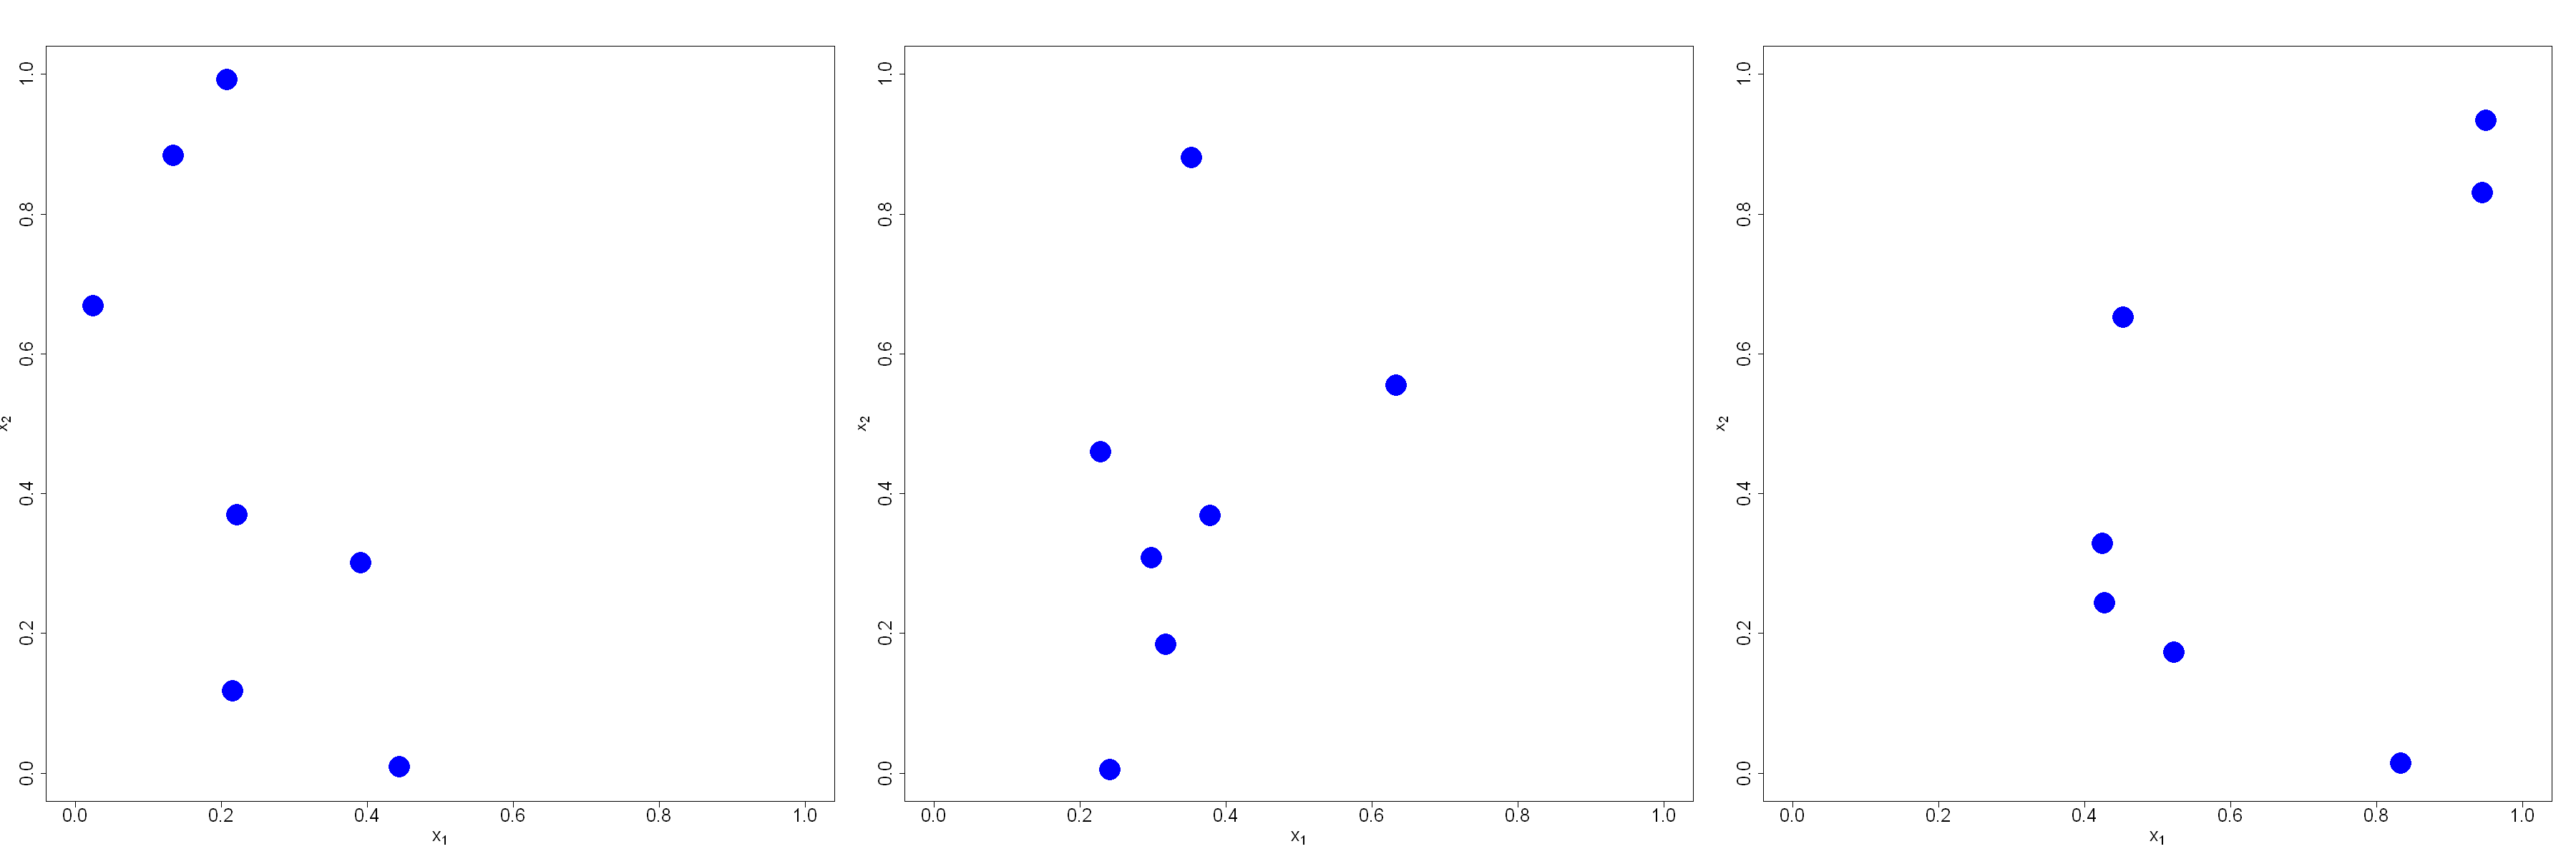

In [2]:
options(repr.plot.width=30,repr.plot.height=10)
par(mfrow=c(1,3))
for(i in c(9,45,31)){
set.seed(i)
D=matrix(runif(7*2),nrow=7,ncol=2)
plot(D,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),pch=16,col="blue",cex=5,cex.lab=2,cex.axis=2)
}

构建响应曲面的高斯过程模型：$h(\boldsymbol{x}) \sim GP(\mu, \tau^2R(\cdot))$。暂且假定均值 $\mu$、方差 $\tau^2$ 以及相关参数 $\theta$ 均为已知。现有观测数据集 $\{(\boldsymbol{x}_i, y_i)\}_{i=1}^n$，则 $h(\boldsymbol{x})$ 的后验分布满足：

$$
h(\boldsymbol{x})|y \sim \mathcal{N}(\hat{y}(\boldsymbol{x}), s^2(\boldsymbol{x}))
$$

其中：

$$
\hat{y}(\boldsymbol{x}) = \mu + \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}(\boldsymbol{y} - \mu\boldsymbol{1})
$$

$$
s^2(\boldsymbol{x}) = \tau^2\left[1 - \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\right]
$$

式中 $\boldsymbol{r}(\boldsymbol{x}) = \{R(\boldsymbol{x}-\boldsymbol{x}_i)\}_{i=1}^n$，矩阵 $\boldsymbol{R} = \{R(\boldsymbol{x}_i-\boldsymbol{x}_j)\}_{i,j=1}^n$，定义形式见式 (2.13)。需要说明的是，$\boldsymbol{r}(\boldsymbol{x})$ 与矩阵 $\boldsymbol{R}$ 均依赖试验设计 $D = \{\boldsymbol{x}_i\}_{i=1}^n$ 和相关参数 $\theta$，为简化符号书写，表达式中并未显式标注该依赖关系。

我们的目标是确定试验设计方案，使得对任意属于试验区域 $\mathcal{X}$ 的自变量 $\boldsymbol{x}$，预测值 $\hat{y}(\boldsymbol{x})$ 尽可能贴近真实响应曲面 $h(\boldsymbol{x})$；经过标准化处理后，试验区域 $\mathcal{X}$ 通常为超立方体 $[0, 1]^p$。二者的接近程度可通过置信区间 $\hat{y}(\boldsymbol{x}) \pm z_{1-\alpha/2}s(\boldsymbol{x})$ 衡量，其中 $z_{1-\alpha/2}$ 为标准正态分布的上 $(1-\alpha/2)$ 分位数。因此优化目标可设定为最小化置信区间宽度 $2z_{1-\alpha/2}s(\boldsymbol{x})$。由于该宽度随自变量 $\boldsymbol{x}$ 变化，我们转而采用积分平均形式：

$$
\min_{D}\int_{\mathcal{X}} s(\boldsymbol{x})w(\boldsymbol{x})d\boldsymbol{x}
$$

式中 $w(x)$ 为权重函数，用于表征响应曲面在位置 $x$ 处的重要程度。现阶段假定研究关注整个试验区域 $X$，即区域内所有 $x$ 的重要性均等。参数 $\tau$ 不会影响优化过程，故令 $\tau=1$。由此得到最优设计准则：最小化积分均方根误差：

$$
IRMSE(D; \theta)=\int_{\mathcal{X}}\sqrt{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})}d\boldsymbol{x}
\tag{3.1}
$$

值得注意，该准则与参数 $\mu$、$\tau^2$ 无关，仅依赖相关参数 $\boldsymbol{\theta}$。式 (3.1) 物理意义更为直观（约瑟夫等人，2019），但在求解最优设计时，采用积分均方误差在数学计算上更为简便（萨克斯等人，1989）：

$$
\begin{align*}
IMSE(D; \theta)&=\int_{\mathcal{X}}\left\{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}d\boldsymbol{x} \tag{3.2}\\
&=1-tr\left( \boldsymbol{R}^{-1}\int_{\mathcal{X}} \boldsymbol{r}(\boldsymbol{x})\boldsymbol{r}(\boldsymbol{x})'d\boldsymbol{x} \right)
\end{align*}
$$

上式中 $\mathcal{X} = [0, 1]^p$。当选取特定相关函数（例如高斯相关函数）时，该准则可完成解析积分求解（莱瑟曼等人，2018），从而简化优化运算。

我们考虑一维算例,便于直观理解该设计准则.积分均方误差准则需先指定相关函数及其参数方可计算,取相关函数$R(x)=\exp(-x^{2}/\theta^{2})$,令相关参数$\theta=0.1$.图3.2左上子图展示两种含10次试验的设计对应的均方根误差RMSE(等价于标准化后验标准差$s(\boldsymbol{x})/\tau$):等距设计

$$D_{1}=\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}$$

与切比雪夫设计

$$D_{2}=\left\{0.5+0.5\cos\left(\pi\frac{i-0.5}{n}\right)\right\}_{i=1}^{n}$$

其中试验次数$n=10$.可以看到,在试验点处RMSE取值为0,且随预测点远离试验点逐步增大;切比雪夫设计在边界附近分配更多样本点,因此边界区域RMSE更小,但区间中部的RMSE会有所升高.我们可通过计算式(3.2)中的IMSE对比两种设计优劣,借助数值积分求得$\mathrm{IMSE}(D_{1};0.1)=0.0705$,$\mathrm{IMSE}(D_{2};0.1)=0.1227$,说明等距设计表现更优.我们可通过优化IMSE准则求解最优设计,但该优化问题求解难度较大:目标函数包含矩阵逆$\boldsymbol{R}^{-1}$,依赖数值积分且存在多极值.本文采用R语言内置`optim`函数中的无导数有限内存BFGS(L-BFGS)优化算法,以等距设计作为初始迭代点求解最优设计.最优设计$D_{3}$绘制于同一张图的左下子图,对应指标$\mathrm{IMSE}(D_{3};0.1)=0.0496$;可见该最优设计将样本点向区间中部聚拢,致使边界位置RMSE变大,但整体积分均方误差更小.

注意存在不等式关系:

$$\int_{\mathcal{X}}(1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x}))\mathrm{d}\boldsymbol{x}\le\max_{\boldsymbol{x}\in\mathcal{X}}(1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x}))$$

由此可定义另一类优化准则:最小化最大均方误差(萨克斯等人,1989):

$$\mathrm{MMSE}(D;\boldsymbol{\theta})=\max_{\boldsymbol{x}\in\mathcal{X}}(1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x}))\tag{3.3}$$

基于积分均方误差(IMSE)与最大均方误差(MMSE)求得的设计,可类比线性回归模型中的I最优设计(式2.37)与G最优设计(式2.36),二者分别是高斯过程框架下的对应准则.

通过最小化最大均方误差(MMSE)得到的最优设计$D_{4}$展示在图3.2的右下子图.可以看到该设计能够抑制全局最大预测不确定性;相较于积分均方误差(IMSE)最优设计,它将样本点适度向区间边界偏移.图3.2同时标注了全部四类设计对应的MMSE指标数值.

> **图 3.2** 四种试验设计对应的均方根误差。若依托对应设计采集的数据拟合高斯过程模型，且模型相关函数取 $R(\Delta) = \exp(-\Delta^2/\theta^2)$、$\theta=0.1$，则纵坐标正比于置信区间宽度。

In [ ]:
#图3.2

library(gpcrit)

##等距

options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
theta=.1
n=10
test=seq(0,1,length=301)
D=((1:n)-1)/(n-1)
sa=gp_rmse(D,theta,test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="等距设计",lwd=4,cex.main=3,cex.lab=2,cex.axis=2)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

##切比雪夫

D=.5+.5*cos((pi*(1:n)-.5)/n)
sa=gp_rmse(D,theta,test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="切比雪夫设计",lwd=4,cex.main=3,cex.lab=2,cex.axis=2)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

##IMSE

D0=((1:n)-.5)/n
a=optim(D0,function(D)imse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
D=a$par
sa=gp_rmse(D,theta,test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="IMSE最优设计",lwd=4,cex.main=3,cex.lab=2,cex.axis=2)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

##MMSE

a=optim(D0,function(D)mmse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
D=a$par
sa=gp_rmse(D,theta,test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="MMSE最优设计",lwd=4,cex.main=3,cex.lab=2,cex.axis=2)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)
par(mfrow=c(1,1))

前文全部数值计算均基于高斯相关函数,且设定尺度参数$\theta=0.1$完成.在实际场景中,开展试验前我们无法预先获知尺度参数取值,因此有必要探究该参数是否会对最优设计产生影响.图3.3上方两幅子图绘制了积分均方误差(IMSE)与最大均方误差(MMSE)随$\theta$的变化曲线,可见两项指标均会随$\theta$发生显著变动;当$\theta$取值极小或极大时,四类设计的表现趋于相近,该现象具备合理解释:$\theta$较小时代表响应曲面起伏剧烈,所有含10次试验的设计对曲面的拟合效果都较差;反之$\theta$较大时对应光滑响应曲面,各类设计均能实现较好拟合;仅当$\theta$处于中间区间时,不同设计的性能才会出现明显分化.参照萨克斯等人(1989)的思路,我们可定义相对效率指标以更清晰区分各设计优劣,对应公式如下:

$$\begin{align*}\mathrm{RE}_{\mathrm{I}}(D_{i};\boldsymbol{\theta})&=\frac{\min_{i}\mathrm{IMSE}(D_{i};\boldsymbol{\theta})}{\mathrm{IMSE}(D_{i};\boldsymbol{\theta})}\\\mathrm{RE}_{\mathrm{M}}(D_{i};\boldsymbol{\theta})&=\frac{\min_{i}\mathrm{MMSE}(D_{i};\boldsymbol{\theta})}{\mathrm{MMSE}(D_{i};\boldsymbol{\theta})}\end{align*}$$

式中下标$i=1,2,3,4$.

四类设计分别基于积分均方误差(IMSE)与最大均方误差(MMSE)计算得到的相对效率曲线绘制于图3.3下方两幅子图,可见最优设计会随尺度参数$\theta$的取值发生改变;例如切比雪夫设计在$\theta<0.3$时积分均方误差表现较差,但当$\theta>0.3$时反而是最优方案,这一结论对前述最优设计方法而言十分不利,不过仍存在可行解决思路:等距设计与MMSE最优设计虽无法在全部$\theta$取值下达到最优,但整体性能始终维持在较好水平,因此我们需要构造对参数$\theta$具备鲁棒性的试验设计,对应优化模型定义如下:

$$\max_{D}\min_{\boldsymbol{\theta}\in\Theta}\frac{\mathrm{IMSE}(D^*(\boldsymbol{\theta});\boldsymbol{\theta})}{\mathrm{IMSE}(D;\boldsymbol{\theta})}$$

其中

$$D^*(\boldsymbol{\theta})=\argmin_{D}\mathrm{IMSE}(D;\boldsymbol{\theta})$$

参数可行域满足$\Theta\subset[0,\infty)^{p}$;鲁棒MMSE最优设计可采用完全相同的方式定义.该优化问题求解难度极高,即便对$p$维参数空间$\Theta$进行离散化处理,仍需要针对大量不同的$\boldsymbol{\theta}$分别求解IMSE最优或MMSE最优设计.

>**图3.3** 图3.2中四种设计相对于IMSE与MMSE准则的相对效率.IMSE最优设计与MMSE最优设计通过固定参数$\theta=0.1$求得

In [12]:
#图3.3

r=function(x,D)exp(-(outer(x,D,"-")/theta)^2)
s=function(x){
Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
sqrt(1-colSums(t(r(x,D))*Z))
}
imse=function(D){
R=r(D,D)
s=function(x){
Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
1-colSums(t(r(x,D))*Z)
}
integrate(s,0,1)$val
}
mmse=function(D){
R=r(D,D)
s=function(x){
Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
1-colSums(t(r(x,D))*Z)
}
test=seq(0,1,length=301)
max(s(test))
}
n=10
theta=.1
D1=((1:n)-1)/(n-1)
D2=.5+.5*cos((pi*(1:n)-.5)/n)
D0=((1:n)-.5)/n
D3=optim(D0,imse,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
D4=optim(D0,mmse,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par

options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
ev=seq(.01,.4,length=301)
IR=MR=matrix(0,nrow=301,ncol=4)
for(i in 1:301){
theta=ev[i]
IR[i,]=c(imse(D1),imse(D2),imse(D3),imse(D4))
MR[i,]=c(mmse(D1),mmse(D2),mmse(D3),mmse(D4))
}

matplot(ev,IR,type="l",xlab=expression(theta),ylab="IMSE",lwd=4,main="IMSE",cex.main=3,cex.lab=2,cex.axis=2)
legend(.1,1,legend=c("等距设计","切比雪夫设计","IMSE最优设计","MMSE最优设计"),lty=1:4,col=1:4,lwd=4,bty="n",cex=2)
matplot(ev,MR,type="l",xlab=expression(theta),ylab="MMSE",lwd=4,main="MMSE",cex.main=3,cex.lab=2,cex.axis=2)

IRR=apply(IR,1,min)/IR
matplot(ev,IRR,type="l",xlab=expression(theta),ylab="RE",lwd=4,main="基于IMSE的相对效率",cex.main=3,cex.lab=2,cex.axis=2)
MRR=apply(MR,1,min)/MR
matplot(ev,MRR,type="l",xlab=expression(theta),ylab="RE",lwd=4,main="基于MMSE误差的相对效率",cex.main=3,cex.lab=2,cex.axis=2)
par(mfrow=c(1,1))

由图3.3可见,当$\theta\to0$(即相关系数趋近于0,变量近似相互独立)时,所有设计的拟合效果均不理想;该极限情形下相关矩阵$\boldsymbol{R}$退化为单位矩阵$\boldsymbol{I}$,计算积分均方误差(IMSE)与最大均方误差(MMSE)准则时无需对$\boldsymbol{R}$求逆,大幅降低计算开销,并且在此极限条件下求得的设计,在强相关场景中同样具备不错表现.这类设计被称作填充空间设计,构造难度更低,同时对相关结构设定偏差具备良好鲁棒性,因此本书将填充空间设计作为计算机试验的初始设计使用.不过在深入讲解填充空间设计前,我们还需要掌握基于模型的试验设计中的另一核心概念.